# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

Week 9, Day 1 - Bank Customer Churn

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

For every hypothesis we use a significance level **α = 0.05**: if p < 0.05 we reject H0.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [2]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [3]:
import os

# Local copy in the repo; otherwise read the zip provided by the bootcamp
file_1 = "data/Churn_Modelling.csv"
if not os.path.exists(file_1):
    file_1 = ("https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/"
              "Week%205/Day%204%20-%20Statistics%20for%20Machine%20Learning/Inferential%20Statistics.zip")

In [4]:
df = pd.read_csv(file_1)
print(df.shape)

(10000, 14)


In [5]:
display(df.head())
print("Missing values:", df.isnull().sum().sum())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Missing values: 0


In [6]:
df_0 = df[df['Exited'] == 0]   # still with the bank
df_1 = df[df['Exited'] == 1]   # left the bank

print(f"Stayed: {len(df_0)} customers | Left: {len(df_1)} customers ({len(df_1) / len(df):.1%} churn rate)")

Stayed: 7963 customers | Left: 2037 customers (20.4% churn rate)


In [7]:
alpha = 0.05

def report(name, t_stat, p_value):
    print(f"{name}: t = {t_stat:.4f}, p-value = {p_value:.4g}")
    print("-> Reject H0" if p_value < alpha else "-> Fail to reject H0")

## Hypothesis 1: Age

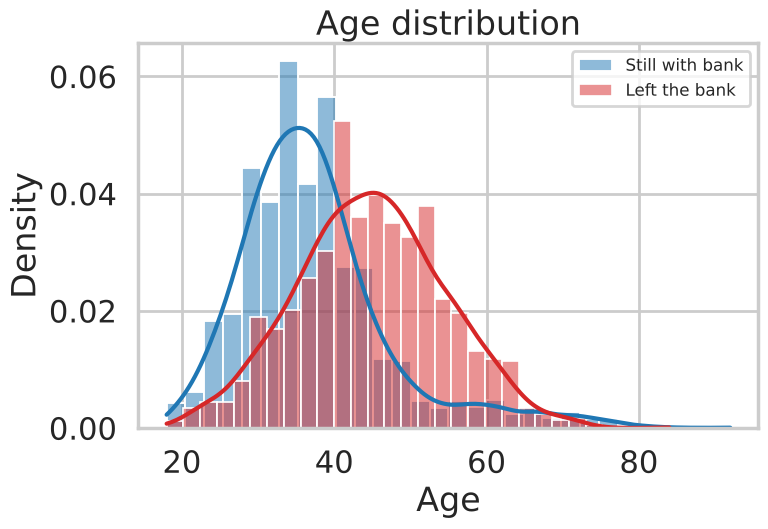

In [8]:
plt.figure()
sns.histplot(df_0['Age'], color='tab:blue', label='Still with bank', kde=True, stat='density', bins=30, alpha=0.5)
sns.histplot(df_1['Age'], color='tab:red', label='Left the bank', kde=True, stat='density', bins=30, alpha=0.5)
plt.title('Age distribution')
plt.legend(fontsize=12)
plt.show()

In [9]:
age_mean_0, age_std_0 = df_0['Age'].mean(), df_0['Age'].std()
print(f"Stayed - mean age: {age_mean_0:.2f}, std: {age_std_0:.2f}")

Stayed - mean age: 37.41, std: 10.13


In [10]:
age_mean_1, age_std_1 = df_1['Age'].mean(), df_1['Age'].std()
print(f"Left   - mean age: {age_mean_1:.2f}, std: {age_std_1:.2f}")

Left   - mean age: 44.84, std: 9.76


In [11]:
# Welch's t-test (the two groups don't have the same size or variance)
t_age, p_age = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'], equal_var=False)
report("Age t-test", t_age, p_age)

Age t-test: t = -30.4192, p-value = 4.713e-179
-> Reject H0


### Using Bootstrapping

In [12]:
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data))
        bs_s[i] = func(bs_abc)
    return bs_s

In [13]:
# Observed difference in means
empirical_diff_age = age_mean_1 - age_mean_0
print(f"Observed difference in mean age (left - stayed): {empirical_diff_age:.2f} years")

# Shift both groups so they share the overall mean: this simulates H0 (same mean)
overall_mean_age = df['Age'].mean()
age_0_shifted = df_0['Age'] - age_mean_0 + overall_mean_age
age_1_shifted = df_1['Age'] - age_mean_1 + overall_mean_age

Observed difference in mean age (left - stayed): 7.43 years


Bootstrap std of the mean - stayed: 0.1149, left: 0.2166
Bootstrap std of the difference: 0.2431


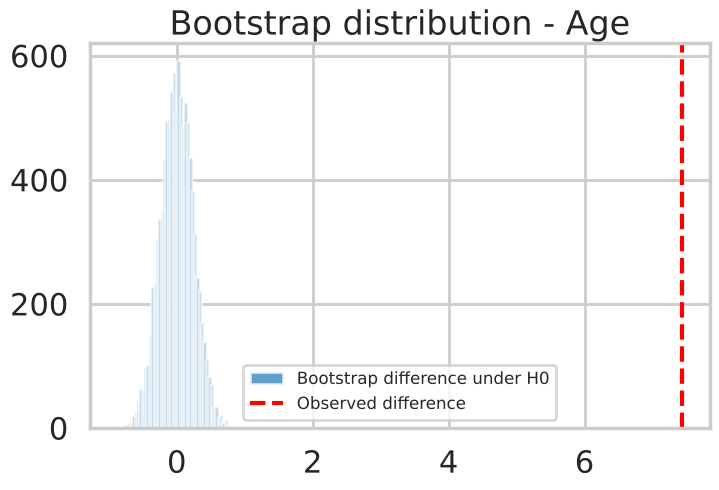

In [14]:
seed(42)
n_bs = 10000

# Bootstrap replicates of the mean under H0
bs_mean_0 = bs_choice(age_0_shifted, np.mean, n_bs)
bs_mean_1 = bs_choice(age_1_shifted, np.mean, n_bs)
bs_diff_age = bs_mean_1 - bs_mean_0

print(f"Bootstrap std of the mean - stayed: {bs_mean_0.std():.4f}, left: {bs_mean_1.std():.4f}")
print(f"Bootstrap std of the difference: {bs_diff_age.std():.4f}")

plt.figure()
plt.hist(bs_diff_age, bins=50, alpha=0.7, label='Bootstrap difference under H0')
plt.axvline(empirical_diff_age, color='red', linestyle='--', label='Observed difference')
plt.title('Bootstrap distribution - Age')
plt.legend(fontsize=12)
plt.show()

In [15]:
# Two-sided p-value: share of bootstrap differences at least as extreme as the observed one
p_bs_age = np.mean(np.abs(bs_diff_age) >= np.abs(empirical_diff_age))
print(f"Bootstrap p-value: {p_bs_age}")

Bootstrap p-value: 0.0


### Conclusion
**Yes, we reject the null hypothesis.** Customers who left are on average about 7.4 years older (≈ 44.8 vs 37.4). The t-test gives a p-value far below 0.05, and none of the 10,000 bootstrap differences simulated under H0 is as large as the observed one (bootstrap p-value = 0). Age is clearly different between the two groups: churn is concentrated among customers in their 40s–50s, not among the youngest ones as one might expect.

## Hypothesis 2: Credit Score

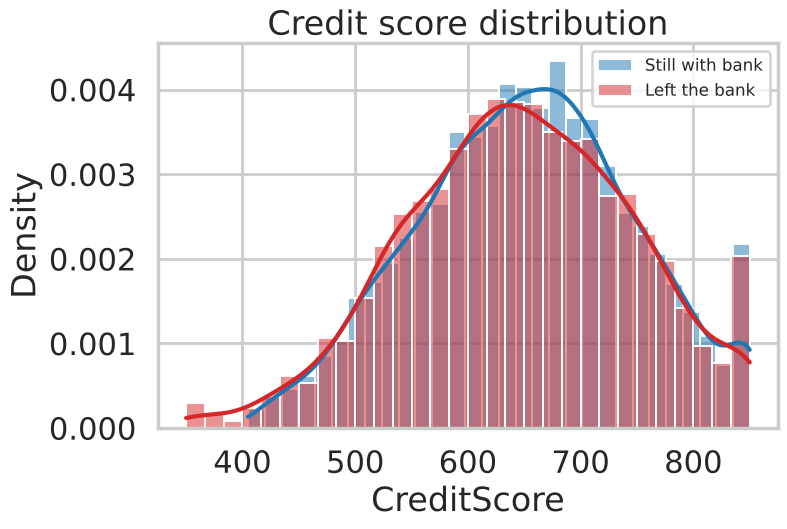

In [16]:
plt.figure()
sns.histplot(df_0['CreditScore'], color='tab:blue', label='Still with bank', kde=True, stat='density', bins=30, alpha=0.5)
sns.histplot(df_1['CreditScore'], color='tab:red', label='Left the bank', kde=True, stat='density', bins=30, alpha=0.5)
plt.title('Credit score distribution')
plt.legend(fontsize=12)
plt.show()

In [17]:
print(f"Mean credit score - stayed: {df_0['CreditScore'].mean():.2f}, left: {df_1['CreditScore'].mean():.2f}")
t_cs, p_cs = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False)
report("Credit score t-test", t_cs, p_cs)

Mean credit score - stayed: 651.85, left: 645.35
Credit score t-test: t = 2.6347, p-value = 0.008465
-> Reject H0


### Conclusion
**Yes, we reject the null hypothesis, but only just.** The p-value (≈ 0.008) is below 0.05, so the difference is statistically significant. However, it is tiny in practice: the means differ by only about 6 points (≈ 652 vs 645) on a scale from 350 to 850, and the two distributions almost completely overlap. With 10,000 customers, even a very small difference becomes significant. Credit score alone will not be a strong churn predictor.

## Hypothesis 3: Balance

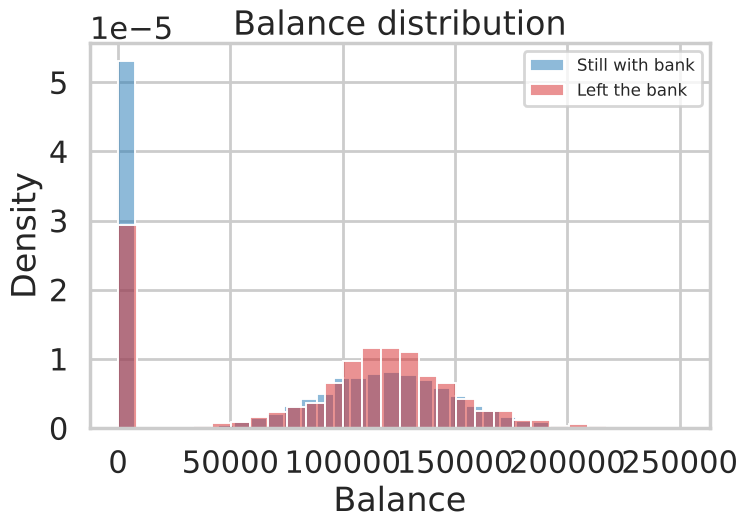

Share of zero balances - stayed: 39.1%, left: 24.5%


In [18]:
plt.figure()
sns.histplot(df_0['Balance'], color='tab:blue', label='Still with bank', stat='density', bins=30, alpha=0.5)
sns.histplot(df_1['Balance'], color='tab:red', label='Left the bank', stat='density', bins=30, alpha=0.5)
plt.title('Balance distribution')
plt.legend(fontsize=12)
plt.show()

print(f"Share of zero balances - stayed: {(df_0['Balance'] == 0).mean():.1%}, left: {(df_1['Balance'] == 0).mean():.1%}")

In [19]:
print(f"Mean balance - stayed: {df_0['Balance'].mean():.2f}, left: {df_1['Balance'].mean():.2f}")
t_bal, p_bal = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False)
report("Balance t-test", t_bal, p_bal)

Mean balance - stayed: 72745.30, left: 91108.54
Balance t-test: t = -12.4713, p-value = 6.319e-35
-> Reject H0


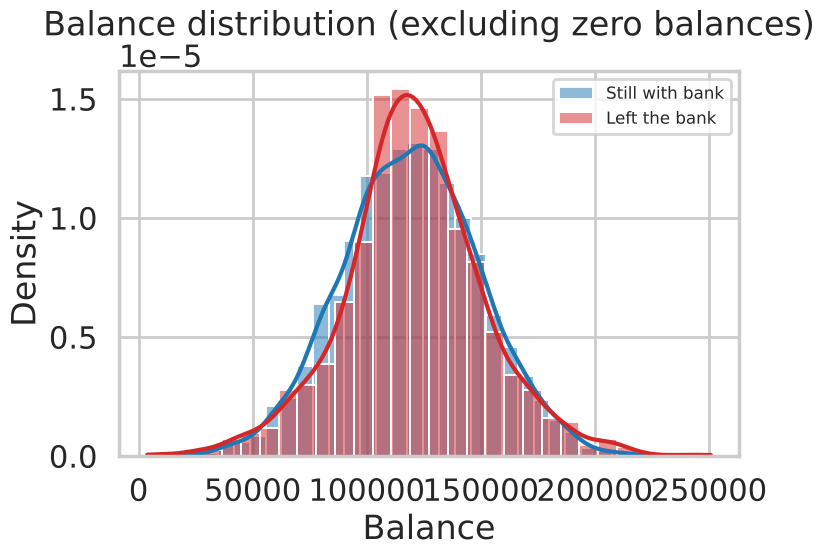

In [20]:
df_0_nz = df_0[df_0['Balance'] > 0]
df_1_nz = df_1[df_1['Balance'] > 0]

plt.figure()
sns.histplot(df_0_nz['Balance'], color='tab:blue', label='Still with bank', kde=True, stat='density', bins=30, alpha=0.5)
sns.histplot(df_1_nz['Balance'], color='tab:red', label='Left the bank', kde=True, stat='density', bins=30, alpha=0.5)
plt.title('Balance distribution (excluding zero balances)')
plt.legend(fontsize=12)
plt.show()

In [21]:
print(f"Mean non-zero balance - stayed: {df_0_nz['Balance'].mean():.2f}, left: {df_1_nz['Balance'].mean():.2f}")
t_bal_nz, p_bal_nz = scipy.stats.ttest_ind(df_0_nz['Balance'], df_1_nz['Balance'], equal_var=False)
report("Balance t-test (non-zero)", t_bal_nz, p_bal_nz)

Mean non-zero balance - stayed: 119535.86, left: 120746.97
Balance t-test (non-zero): t = -1.3605, p-value = 0.1738
-> Fail to reject H0


## Conclusion

**With all customers: yes, we reject the null hypothesis.** Those who left have a clearly higher mean balance (≈ 91k vs 73k), with a p-value far below 0.05. But the distribution has a large peak at 0: about 39% of the customers who stayed have a zero balance, against only 25% of those who left.

**Excluding zero balances: we fail to reject the null hypothesis** (p ≈ 0.17 > 0.05). The mean balances become almost identical (≈ 120.7k vs 119.5k). So the whole difference comes from the *share of customers with a zero balance*, not from the amount held by the others. Contrary to intuition, customers who leave are *not* the ones with low balances: having money in the account (and not using other products) is associated with more churn.

## Hypothesis 4: Estimated Salary

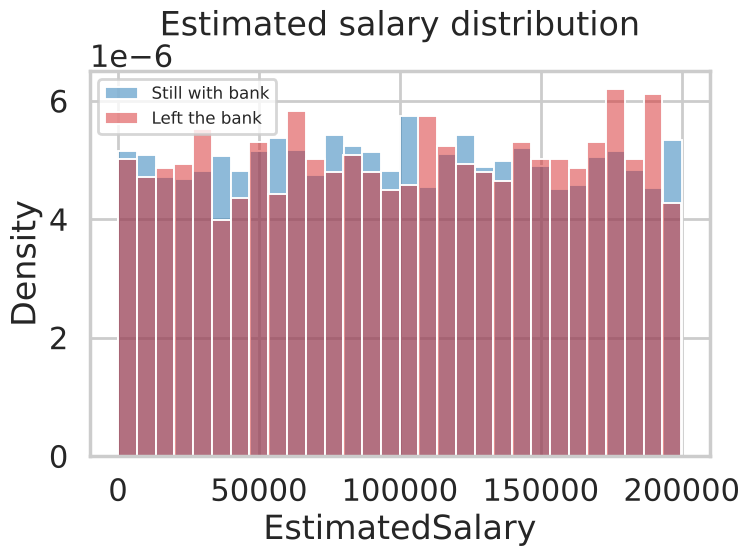

In [22]:
plt.figure()
sns.histplot(df_0['EstimatedSalary'], color='tab:blue', label='Still with bank', stat='density', bins=30, alpha=0.5)
sns.histplot(df_1['EstimatedSalary'], color='tab:red', label='Left the bank', stat='density', bins=30, alpha=0.5)
plt.title('Estimated salary distribution')
plt.legend(fontsize=12)
plt.show()

In [23]:
sal_mean_0, sal_mean_1 = df_0['EstimatedSalary'].mean(), df_1['EstimatedSalary'].mean()
print(f"Mean salary - stayed: {sal_mean_0:.2f}, left: {sal_mean_1:.2f}")
t_sal, p_sal = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'], equal_var=False)
report("Estimated salary t-test", t_sal, p_sal)

Mean salary - stayed: 99738.39, left: 101465.68
Estimated salary t-test: t = -1.2034, p-value = 0.2289
-> Fail to reject H0


### Using Bootstrapping

In [24]:
empirical_diff_sal = sal_mean_1 - sal_mean_0
print(f"Observed difference in mean salary (left - stayed): {empirical_diff_sal:.2f}")

overall_mean_sal = df['EstimatedSalary'].mean()
sal_0_shifted = df_0['EstimatedSalary'] - sal_mean_0 + overall_mean_sal
sal_1_shifted = df_1['EstimatedSalary'] - sal_mean_1 + overall_mean_sal

Observed difference in mean salary (left - stayed): 1727.29


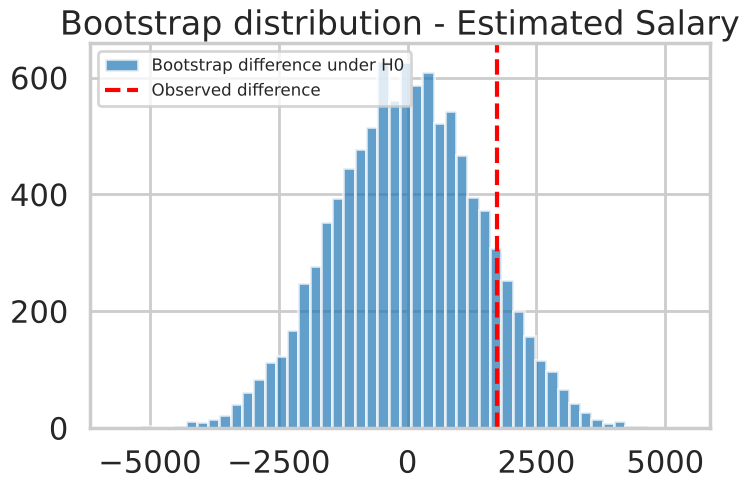

In [25]:
seed(42)
bs_sal_0 = bs_choice(sal_0_shifted, np.mean, n_bs)
bs_sal_1 = bs_choice(sal_1_shifted, np.mean, n_bs)
bs_diff_sal = bs_sal_1 - bs_sal_0

plt.figure()
plt.hist(bs_diff_sal, bins=50, alpha=0.7, label='Bootstrap difference under H0')
plt.axvline(empirical_diff_sal, color='red', linestyle='--', label='Observed difference')
plt.title('Bootstrap distribution - Estimated Salary')
plt.legend(fontsize=12)
plt.show()

In [26]:
p_bs_sal = np.mean(np.abs(bs_diff_sal) >= np.abs(empirical_diff_sal))
print(f"Bootstrap p-value: {p_bs_sal:.4f}")

Bootstrap p-value: 0.2275


### Conclusion
**No, we fail to reject the null hypothesis.** The mean salaries are almost the same (≈ 101.5k for those who left vs 99.7k for those who stayed). Both the t-test and the bootstrap give a p-value well above 0.05 (≈ 0.23): the observed difference falls in the middle of the bootstrap distribution simulated under H0. Estimated salary is almost uniformly distributed in both groups, so it carries no useful information about churn.

## Final Conclusion
What will be the most helpful feature in predicting churning?

In [27]:
summary = pd.DataFrame({
    'Mean (stayed)': [df_0[c].mean() for c in ['Age', 'CreditScore', 'Balance', 'EstimatedSalary']],
    'Mean (left)': [df_1[c].mean() for c in ['Age', 'CreditScore', 'Balance', 'EstimatedSalary']],
    't-statistic': [t_age, t_cs, t_bal, t_sal],
    'p-value': [p_age, p_cs, p_bal, p_sal],
}, index=['Age', 'CreditScore', 'Balance', 'EstimatedSalary'])
summary['Reject H0 (α=0.05)'] = summary['p-value'] < alpha
display(summary.round(4))

,Mean (stayed),Mean (left),t-statistic,p-value,Reject H0 (α=0.05)
Age,37.4084,44.8380,-30.4192,0.0000,True
CreditScore,651.8532,645.3515,2.6347,0.0085,True
Balance,72745.2968,91108.5393,-12.4713,0.0000,True
EstimatedSalary,99738.3918,101465.6775,-1.2034,0.2289,False


**Age is the most helpful feature to predict churn.** It has by far the largest test statistic (|t| ≈ 30) and the clearest separation between the two distributions: customers who leave are on average 7 years older.

- **Age**: strong, significant difference → the best predictor.
- **Balance**: significant difference, entirely driven by whether the balance is zero → a useful second predictor (a "zero balance" flag is more informative than the amount).
- **Credit score**: statistically significant but negligible in practice → weak predictor.
- **Estimated salary**: no significant difference → not useful.

**Business recommendation:** the bank should target its retention efforts at customers aged roughly 40–60, and at customers who hold a balance but few other products. Offering them additional products or personalised advice could reduce churn. A machine learning model built on these features should give the most weight to Age and Balance.